In [1]:
import sys
print(sys.executable)

d:\Projects\ocr-document-understanding\.venv\Scripts\python.exe


# First OCR Run — Tesseract

Goal: load one image from `sample_images/`, run Tesseract on it,
and inspect the output. This is exploratory — once we know the
shape of Tesseract's output, we'll port the working code into
`src/ocr.py`.

In [2]:
import cv2
import pytesseract
from pathlib import Path
import matplotlib.pyplot
import matplotlib.pyplot as plt

In [3]:
project_root = Path.cwd().parent
image_path = project_root / "sample_images" / "sroie_05.jpg"

print("Looking for:", image_path)
print("Exists?", image_path.exists())

Looking for: d:\Projects\ocr-document-understanding\sample_images\sroie_05.jpg
Exists? True


In [4]:
image = cv2.imread(str(image_path))

print("Image loaded:", image is not None)
print("Image shape:", image.shape)

Image loaded: True
Image shape: (1646, 544, 3)


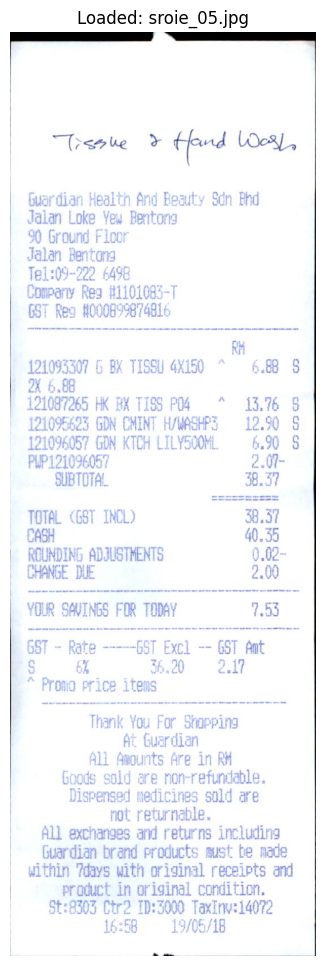

In [5]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (8, 12))
plt.imshow(image_rgb)
plt.axis("off")
plt.title(f"Loaded: {image_path.name}")
plt.show()

In [6]:
text = pytesseract.image_to_string(image)

print("---- RAW TEXT FROM TESSERACT ----")
print(text)
print("---- END ----")

---- RAW TEXT FROM TESSERACT ----
Tepe ¥ cpa LOeXL,

guardian Health And Beauty Sdn Bhd
Jalan Loke Yew Bentong

90 Ground Floor

Jalan Bentona
Jel:09-222 6498
Company Rea H#1101085-T
OST Rea HOOOBSSB74B14

121093307 G BX TISSU 4X50 * 6.88 §
121087265 HK PX TISS POG * (13,78 §
§
8

21095623 GON CHINT HAWASHPS = 12.9
96057 GDN KTCH LILYSOOML 4,90
PUP 121096057 2.07-
SUBTOTAL 36.37
a“ ¢G8T INCL) 38.37
CASH 40.46
= ADJUSTMENTS 9.02-

All i ts Are in RH
old are non-refundable.
1 medicines sold are
not returnable.
ALL exchanges and returns including
Guardian brand products aust be nade
within ?days with original receipts and
product in original condition.
S$t:8303 Chr? 1D:5000 Taxinv:14072
16:68 L305 /18


---- END ----


In [7]:
data = pytesseract.image_to_data(image, output_type = pytesseract.Output.DICT)

print("Keys returned:", list(data.keys()))
print("Number of items detected:", len(data["text"]))

Keys returned: ['level', 'page_num', 'block_num', 'par_num', 'line_num', 'word_num', 'left', 'top', 'width', 'height', 'conf', 'text']
Number of items detected: 193


In [8]:
# Print the first 15 entries where confidence is > 0 (i.e., actual recognized text)
print(f"{'idx':>4} {'conf':>5} {'left':>5} {'top':>5} {'w':>4} {'h':>4}  text")
print("-" * 50)

count = 0
for i in range(len(data["text"])):
    if int(data["conf"][i]) > 0 and data["text"][i].strip() != "":
        print(f"{i:>4} {data['conf'][i]:>5} {data['left'][i]:>5} {data['top'][i]:>5} "
              f"{data['width'][i]:>4} {data['height'][i]:>4}  {data['text'][i]}")
        count += 1
        if count >= 15:
            break

 idx  conf  left   top    w    h  text
--------------------------------------------------
  13    57   249   181   21   23  ¥
  19    51    34   286   94   25  guardian
  20    95   142   285   71   25  Health
  21    96   226   285   35   25  And
  22    62   274   285   70   25  Beauty
  23    86   360   285   33   24  Sdn
  24    90   408   284   34   25  Bhd
  26    90    32   317   59   25  Jalan
  27    90   105   318   46   25  Loke
  28    85   166   318   33   25  Yew
  29    19   214   318   82   25  Bentong
  32    93    33   352   23   25  90
  33    95    69   352   71   25  Ground
  34    39   153   352   55   24  Floor
  37    89    31   383   79   25  Jalan


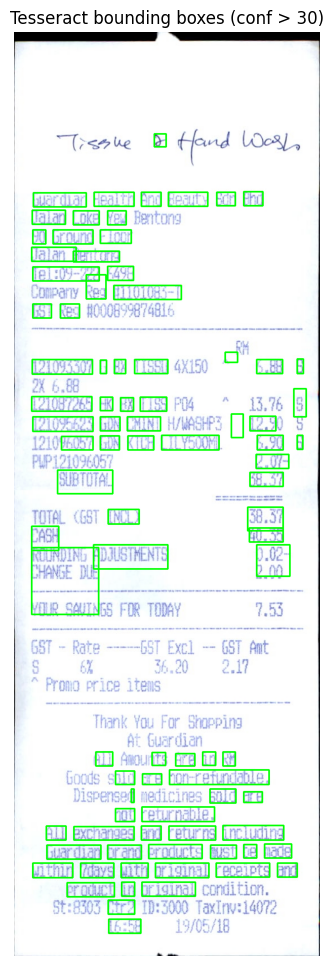

In [9]:
# Make a copy of the image so we don't draw on the original
annotated = image.copy()

# Loop through each detected text item
for i in range(len(data["text"])):
    conf = int(data["conf"][i])
    text = data["text"][i].strip()
    
    # Only draw boxes for items with real text and confidence > 30
    if conf > 30 and text != "":
        x = data["left"][i]
        y = data["top"][i]
        w = data["width"][i]
        h = data["height"][i]
        
        # Draw a green rectangle. cv2.rectangle takes top-left and bottom-right corners.
        cv2.rectangle(annotated, (x, y), (x + w, y + h), (0, 255, 0), 2)

# Convert BGR → RGB for matplotlib, then display
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 12))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Tesseract bounding boxes (conf > 30)")
plt.show()